# Laboratorio 4 — Fundamentos de Aprendizaje por Refuerzo y Gymnasium

**CC3092 · Deep Learning y Sistemas Inteligentes**
Autor: Esteban Cárcamo (`ecarcamo`)

Este notebook contiene los tres bloques del laboratorio:

1. **Investigación** de los fundamentos del aprendizaje por refuerzo (RL).
2. **Investigación** de la librería **Gymnasium**.
3. **Módulo de prueba**: un agente aleatorio en dos entornos (CartPole-v1 y
   FrozenLake-v1) y una política simple *no aprendida* para CartPole-v1, con las
   gráficas de recompensa por episodio y la comparación de desempeño.

> Cada afirmación de las secciones 1 y 2 se acompaña de al menos una fuente. Las
> referencias completas están al final de cada sección.

## 1. Fundamentos del aprendizaje por refuerzo

El aprendizaje por refuerzo (*Reinforcement Learning*, RL) estudia cómo un
**agente** aprende a tomar decisiones interactuando con un **entorno** para
maximizar una señal de recompensa acumulada. A continuación se investigan sus
conceptos fundamentales.

### 1.1 ¿Qué es RL y en qué se diferencia del aprendizaje supervisado y no supervisado?

El **aprendizaje por refuerzo** es un paradigma en el que un agente aprende *por
ensayo y error*: en cada instante observa el estado del entorno, ejecuta una
acción y recibe una **recompensa** escalar (posiblemente retrasada). Su objetivo
es descubrir, sin que nadie le indique la acción correcta, la estrategia que
maximiza la recompensa acumulada a lo largo del tiempo.

Diferencias clave con los otros paradigmas:

| | Aprendizaje **supervisado** | Aprendizaje **no supervisado** | Aprendizaje por **refuerzo** |
|---|---|---|---|
| Datos | Pares (entrada, etiqueta correcta) | Datos sin etiqueta | Experiencia (estado, acción, recompensa) generada al interactuar |
| Señal | *Instructiva*: cuál era la respuesta correcta | Ninguna; busca estructura | *Evaluativa*: qué tan buena fue la acción |
| Objetivo | Generalizar un mapeo entrada→salida | Descubrir patrones/estructura | Maximizar la recompensa acumulada |

Además, en RL **las acciones afectan los estados y las recompensas futuras** (los
datos no son i.i.d., hay dependencia temporal), la recompensa puede llegar con
retraso —lo que crea el problema de **asignación de crédito**— y aparece el
dilema **exploración vs. explotación**, ausente en los otros paradigmas.

*Fuente:* Sutton & Barto (2018), cap. 1.

### 1.2 Componentes de un problema de RL

- **Agente** (*agent*): el que decide y aprende.
- **Entorno** (*environment*): todo lo externo al agente con lo que este interactúa.
- **Estado** (*state*) $s$: representación de la situación del entorno en un instante.
- **Acción** (*action*) $a$: la decisión que toma el agente y que influye en el entorno.
- **Recompensa** (*reward*) $r$: señal escalar de retroalimentación que **define el objetivo**.
- **Política** (*policy*) $\pi$: la estrategia del agente; un mapeo de estados a
  acciones, $\pi(a\mid s)$ (determinista o estocástica).

El ciclo de interacción: en el paso $t$ el agente observa $s_t$, elige $a_t$ según
$\pi$, y el entorno responde con la recompensa $r_{t+1}$ y el nuevo estado
$s_{t+1}$. Este bucle *agente ⇄ entorno* es exactamente la API que implementa
Gymnasium (`reset`/`step`).

*Fuente:* Sutton & Barto (2018), cap. 3; Gymnasium — *Basic Usage*.

### 1.3 Proceso de Decisión de Markov (MDP)

Un **MDP** es el marco matemático formal de un problema de RL. Se define por la
tupla $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$:

- $\mathcal{S}$: conjunto de **estados**.
- $\mathcal{A}$: conjunto de **acciones**.
- $P$: **función de transición**, $P(s' \mid s, a)$ = probabilidad de pasar a $s'$
  dado que en $s$ se tomó $a$ (la *dinámica* del entorno).
- $R$: **función de recompensa**, $R(s, a, s')$ = recompensa esperada de esa transición.
- $\gamma \in [0, 1]$: **factor de descuento**, que pondera cuánto valen las
  recompensas futuras frente a las inmediatas.

Se apoya en la **propiedad de Markov**: el futuro depende únicamente del estado y
la acción actuales, no de toda la historia. El objetivo es hallar la política que
maximiza el **retorno esperado** $G_t = \sum_{k \ge 0} \gamma^{k} r_{t+k+1}$.

*Fuente:* Sutton & Barto (2018), cap. 3; Bellman (1957).

### 1.4 Funciones de valor $V(s)$ y $Q(s,a)$

- **Función de valor de estado** $V^{\pi}(s) = \mathbb{E}_{\pi}[\,G_t \mid S_t = s\,]$:
  el retorno esperado si se parte de $s$ y luego se sigue la política $\pi$.
  Responde: *¿qué tan bueno es estar en este estado?*
- **Función de valor acción-estado** $Q^{\pi}(s,a) = \mathbb{E}_{\pi}[\,G_t \mid S_t = s, A_t = a\,]$:
  el retorno esperado si se parte de $s$, se toma la acción $a$ y luego se sigue $\pi$.
  Responde: *¿qué tan buena es esta acción en este estado?*

**Relación entre ambas:** $V^{\pi}(s) = \sum_a \pi(a\mid s)\, Q^{\pi}(s,a)$.

**Relación con la política óptima:** la política óptima $\pi^{*}$ es *greedy*
respecto de los valores óptimos, $\pi^{*}(s) = \arg\max_a Q^{*}(s,a)$, y
$V^{*}(s) = \max_a Q^{*}(s,a)$. Conocer $Q^{*}$ basta para actuar de forma óptima
**sin necesitar el modelo** $P$ del entorno; por eso $Q$ es la base de métodos de
control como Q-Learning.

*Fuente:* Sutton & Barto (2018), cap. 3.

### 1.5 Ecuación de Bellman

**Intuición:** el valor de un estado se descompone de forma recursiva en la
recompensa inmediata más el valor descontado del estado al que se llega. En una
frase: *«el valor de donde estoy = lo que gano ahora + el valor (descontado) de a
donde voy»*.

Ecuación de Bellman **de expectación** (para una política $\pi$):

$$V^{\pi}(s) = \sum_a \pi(a\mid s) \sum_{s'} P(s'\mid s,a)\,\big[\,R(s,a,s') + \gamma\, V^{\pi}(s')\,\big].$$

Ecuación de Bellman **de optimalidad**:

$$Q^{*}(s,a) = \sum_{s'} P(s'\mid s,a)\,\Big[\,R(s,a,s') + \gamma \max_{a'} Q^{*}(s',a')\,\Big].$$

**Rol:** convierte el cálculo de las funciones de valor en un problema de *punto
fijo*. Es el fundamento de la programación dinámica (*value/policy iteration*) y
de los métodos de diferencias temporales: Q-Learning, por ejemplo, usa el lado
derecho de la ecuación de optimalidad como *objetivo* (*target*) de cada
actualización.

*Fuente:* Sutton & Barto (2018), cap. 3–4.

### 1.6 Dilema exploración vs. explotación

El agente enfrenta un compromiso permanente: **explotar** (elegir la mejor acción
conocida para maximizar la recompensa ahora) frente a **explorar** (probar
acciones inciertas para descubrir opciones potencialmente mejores). Explotar
siempre puede dejarlo atrapado en un óptimo local; explorar siempre desperdicia
recompensa. Dos estrategias habituales:

- **$\varepsilon$-greedy:** con probabilidad $1-\varepsilon$ toma la acción
  *greedy* ($\arg\max_a Q(s,a)$) y con probabilidad $\varepsilon$ toma una acción
  aleatoria uniforme. Es simple y suele usarse con $\varepsilon$ que **decae** con
  el tiempo (más exploración al inicio, más explotación al final).
- **Softmax / Boltzmann:** elige cada acción con probabilidad proporcional a
  $\exp(Q(s,a)/\tau)$. La **temperatura** $\tau$ regula la aleatoriedad: $\tau$
  alto → casi uniforme (mucha exploración); $\tau$ bajo → casi *greedy*. A
  diferencia de $\varepsilon$-greedy, explora *proporcionalmente* a lo prometedora
  que es cada acción.

*Fuente:* Sutton & Barto (2018), cap. 2.

### 1.7 Tareas episódicas/continuas, on/off-policy y model-based/model-free

- **Episódicas vs. continuas.** Las tareas *episódicas* tienen estados terminales
  y se dividen en episodios independientes (p.ej. una partida que termina); las
  *continuas* no tienen fin natural, y el descuento $\gamma < 1$ garantiza que el
  retorno sea finito.
- **On-policy vs. off-policy.** Un método *on-policy* mejora la **misma** política
  que genera los datos (p.ej. SARSA). Un método *off-policy* aprende una política
  *objetivo* distinta de la política de *comportamiento* que explora (p.ej.
  Q-Learning aprende la política greedy mientras explora con $\varepsilon$-greedy).
- **Model-based vs. model-free.** Los métodos *model-based* aprenden o usan un
  modelo de la dinámica $P$ y la recompensa $R$ para **planificar** (p.ej. Dyna).
  Los *model-free* aprenden valores o política directamente de la experiencia, sin
  modelo explícito (p.ej. Q-Learning, SARSA).

*Fuente:* Sutton & Barto (2018), cap. 3, 5, 6 y 8.

### 1.8 Q-Learning

Q-Learning es un algoritmo **model-free**, **off-policy** y de **diferencias
temporales (TD)** que aprende directamente la función de valor óptima $Q^{*}$. Tras
observar la transición $(s, a, r, s')$ actualiza:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,\big[\underbrace{r + \gamma \max_{a'} Q(s',a')}_{\text{objetivo TD}} - Q(s,a)\big].$$

El término entre corchetes es el **error TD**: la diferencia entre el objetivo
*bootstrapeado* ($r + \gamma \max_{a'} Q(s',a')$) y la estimación actual.

- **$\alpha$ (tasa de aprendizaje, $0 < \alpha \le 1$):** cuánto se corrige la
  estimación con cada muestra. Un $\alpha$ alto aprende rápido pero de forma
  inestable/ruidosa; un $\alpha$ bajo es estable pero lento.
- **$\gamma$ (factor de descuento, $0 \le \gamma \le 1$):** cuánto pesan las
  recompensas futuras. $\gamma \to 0$ hace al agente *miope* (solo la recompensa
  inmediata); $\gamma \to 1$ lo hace *previsor* (valora el largo plazo).

Es *off-policy* porque en el objetivo usa $\max_{a'}$ (la acción greedy) aunque la
acción realmente ejecutada haya sido otra (exploratoria): así converge a $Q^{*}$
con independencia de la política de exploración.

*Fuente:* Watkins & Dayan (1992); Sutton & Barto (2018), cap. 6.

### Referencias de la sección 1

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction*
  (2.ª ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html>
- Watkins, C. J. C. H., & Dayan, P. (1992). *Q-learning*. Machine Learning, 8(3–4),
  279–292.
- Bellman, R. (1957). *Dynamic Programming*. Princeton University Press.
- Farama Foundation. *Gymnasium Documentation*. <https://gymnasium.farama.org/>

## 2. La librería Gymnasium

Gymnasium es la librería que usaremos para instanciar entornos de RL y hacer que
un agente interactúe con ellos a través de una API estándar. Esta sección
documenta sus fundamentos y, donde es posible, los ilustra ejecutando código real.

### 2.1 ¿Qué es Gymnasium y qué problema resuelve? Relación con OpenAI Gym

**Gymnasium** es una librería de código abierto, mantenida por la **Farama
Foundation**, que ofrece (a) una **API estándar** para entornos de aprendizaje por
refuerzo y (b) una **colección de entornos** de referencia ya implementados.

El problema que resuelve es la **falta de una interfaz común**: al fijar un
contrato uniforme (`reset` / `step` / espacios de observación y acción),
**desacopla el algoritmo del agente de la implementación del entorno**. Así, un
mismo agente puede entrenarse en cualquier entorno —y un entorno puede probarse
con cualquier agente— sin reescribir código, lo que facilita el *benchmarking* y
la reproducibilidad.

**Relación con OpenAI Gym:** Gymnasium es el **fork mantenido y sucesor oficial**
de OpenAI Gym, que dejó de recibir mantenimiento. Conserva la API de Gym (con
mejoras, como separar el antiguo `done` en `terminated` y `truncated`) y funciona
como reemplazo directo: `import gymnasium as gym`.

*Fuente:* Gymnasium — *Introduction / Basic Usage*; Towers et al. (2024).

### 2.2 Estructura básica de un entorno (`Env`)

Un entorno se crea con `gym.make(id)` y expone cuatro métodos principales:

- **`reset(seed=None, options=None) → (observation, info)`**: reinicia el entorno
  al comienzo de un episodio. Devuelve la **observación inicial** y un diccionario
  `info`. El argumento `seed` fija la aleatoriedad para reproducibilidad.
- **`step(action) → (observation, reward, terminated, truncated, info)`**: aplica
  la acción y avanza un paso. Devuelve la tupla de cinco elementos:
  - `observation`: la nueva observación del estado.
  - `reward` (*float*): la recompensa obtenida en el paso.
  - `terminated` (*bool*): `True` si se alcanzó un **estado terminal del MDP**
    (meta lograda o fallo, p.ej. que el poste caiga).
  - `truncated` (*bool*): `True` si el episodio se cortó por una condición
    **externa al MDP** (típicamente el límite de pasos del *wrapper* `TimeLimit`).
  - `info` (*dict*): información auxiliar de diagnóstico.
- **`render()`**: produce una visualización según el `render_mode` (una ventana o
  un *frame* RGB).
- **`close()`**: libera recursos (ventanas, procesos, etc.).

La distinción `terminated` / `truncated` (que reemplaza al `done` único de Gym) es
importante para el *bootstrapping*: tras una **terminación** real no se descuenta
valor futuro, pero tras un **truncamiento** sí, porque el episodio podría haber
continuado.

*Fuente:* Gymnasium — *Basic Usage* y *Handling Time Limits*.

### 2.3 Espacios de observación y acción (*Spaces*)

Los **espacios** describen formalmente qué observaciones y acciones son válidas.
Todo espacio ofrece `.sample()` (una muestra aleatoria válida) y `.contains(x)`.

- **`Discrete(n)`**: un conjunto finito $\{0, 1, \dots, n-1\}$. Se usa cuando hay
  un número finito de opciones o estados (p.ej. la **acción** de CartPole tiene 2
  valores; el **estado** de FrozenLake tiene 16).
- **`Box(low, high, shape, dtype)`**: una región continua (posiblemente
  multidimensional) de $\mathbb{R}^n$ con cotas inferior y superior. Se usa para
  magnitudes continuas —posiciones, velocidades, ángulos o incluso píxeles— (p.ej.
  la **observación** de CartPole es un `Box` de 4 dimensiones).
- **`MultiDiscrete(nvec)`**: el producto de varios `Discrete`; un vector de enteros
  donde cada componente tiene su propio rango. Útil para controles con varios
  mandos independientes u observaciones factorizadas.

Existen además `MultiBinary`, `Tuple`, `Dict`, `Text`, `Sequence` y `Graph`.

*Fuente:* Gymnasium — *Spaces*.

In [1]:
# Demostración de los tres espacios principales (grounded en la propia librería)
import gymnasium as gym
from gymnasium.spaces import Discrete, Box, MultiDiscrete
import numpy as np

print("gymnasium:", gym.__version__)
print()
print("Discrete(4)          ->", Discrete(4), "| sample:", Discrete(4).sample())
box = Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
print("Box(-1,1,(3,))       ->", box, "| sample:", np.round(box.sample(), 3))
md_space = MultiDiscrete([3, 2, 4])
print("MultiDiscrete([3,2,4]) ->", md_space, "| sample:", md_space.sample())

gymnasium: 1.3.0

Discrete(4)          -> Discrete(4) | sample: 1
Box(-1,1,(3,))       -> Box(-1.0, 1.0, (3,), float32) | sample: [-0.21  -0.912  0.89 ]
MultiDiscrete([3,2,4]) -> MultiDiscrete([3 2 4]) | sample: [1 1 1]


### 2.4 Catálogo de entornos

Gymnasium agrupa sus entornos en familias, entre ellas **Classic Control**
(problemas de control clásico de baja dimensión), **Box2D** (física 2D con el
motor Box2D) y **Toy Text** (rejillas discretas sencillas). La siguiente celda
instancia cuatro entornos y muestra sus **espacios reales**; después se resumen su
objetivo, observación y acción.

In [2]:
# Espacios reales de cuatro entornos del catálogo (verificados en ejecución)
import gymnasium as gym
import numpy as np

for env_id in ["CartPole-v1", "MountainCar-v0", "Acrobot-v1", "FrozenLake-v1"]:
    env = gym.make(env_id)
    print(f"### {env_id}  (familia: {env.spec.entry_point.split(':')[0].split('.')[-2]})")
    print("  observation_space:", env.observation_space)
    print("  action_space     :", env.action_space)
    print("  max_episode_steps:", env.spec.max_episode_steps)
    env.close()
    print()

### CartPole-v1  (familia: classic_control)
  observation_space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  action_space     : Discrete(2)
  max_episode_steps: 500

### MountainCar-v0  (familia: classic_control)
  observation_space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  action_space     : Discrete(3)
  max_episode_steps: 200

### Acrobot-v1  (familia: classic_control)
  observation_space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
  action_space     : Discrete(3)
  max_episode_steps: 500

### FrozenLake-v1  (familia: toy_text)
  observation_space: Discrete(16)
  action_space     : Discrete(4)
  max_episode_steps: 100



Resumen de los cuatro entornos (más un ejemplo de Box2D):

| Entorno | Familia | Objetivo | Espacio de observación | Espacio de acción |
|---|---|---|---|---|
| **CartPole-v1** | Classic Control | Mantener un poste en equilibrio sobre un carro moviéndolo izquierda/derecha | `Box(4)`: posición y velocidad del carro, ángulo y velocidad angular del poste | `Discrete(2)`: empujar izquierda (0) o derecha (1) |
| **MountainCar-v0** | Classic Control | Llevar un carro sin motor suficiente hasta la cima de una colina acumulando impulso | `Box(2)`: posición y velocidad | `Discrete(3)`: acelerar izquierda, no acelerar, acelerar derecha |
| **Acrobot-v1** | Classic Control | Balancear un péndulo doble subactuado para elevar su extremo por encima de una línea | `Box(6)`: $\cos/\sin$ de dos ángulos y sus velocidades angulares | `Discrete(3)`: torque $-1$, $0$ o $+1$ en la articulación |
| **FrozenLake-v1** | Toy Text | Cruzar una rejilla helada desde el inicio hasta la meta sin caer en los agujeros | `Discrete(16)`: índice de la casilla en la rejilla $4\times4$ | `Discrete(4)`: izquierda, abajo, derecha, arriba |
| **LunarLander-v3** | Box2D | Aterrizar suavemente un módulo lunar en la plataforma | `Box(8)`: posición, velocidad, ángulo y contacto de las patas | `Discrete(4)`: motor apagado, izquierdo, principal o derecho |

*Fuente:* Gymnasium — páginas de documentación de cada entorno (*Classic Control*,
*Toy Text*, *Box2D*).

### 2.5 ¿Qué es un *wrapper*?

Un **wrapper** envuelve un `Env` para **modificar o extender su comportamiento sin
tocar el entorno base**, y son **componibles** (se apilan en capas). Ejemplos:

- **`TimeLimit`**: corta el episodio al superar `max_episode_steps`, marcando
  `truncated=True`. `gym.make` lo aplica por defecto a la mayoría de entornos
  registrados (por eso CartPole-v1 se trunca a los 500 pasos).
- **`RecordVideo`**: graba videos de los episodios (usando `render`).
- **`RecordEpisodeStatistics`**: acumula el retorno y la longitud de cada episodio
  dentro de `info`.
- **Normalización**: `NormalizeObservation` / `NormalizeReward` (con media y
  varianza móviles), además de `TransformObservation`, `RescaleAction`,
  `FlattenObservation` o `FrameStack`.

**Propósito:** aplicar preprocesamiento estándar, instrumentar la ejecución y
controlar el ciclo de vida del episodio sin ensuciar ni la lógica del entorno ni la
del agente.

*Fuente:* Gymnasium — *Wrappers*.

### Referencias de la sección 2

- Farama Foundation. *Gymnasium Documentation* — *Basic Usage*, *Spaces*,
  *Wrappers* y páginas de entornos. <https://gymnasium.farama.org/>
- Towers, M., et al. (2024). *Gymnasium: A Standard Interface for Reinforcement
  Learning Environments*. <https://arxiv.org/abs/2407.17032>

## 3. Módulo de prueba: primeros pasos con Gymnasium

El objetivo de esta sección **no** es entrenar un agente inteligente, sino
practicar la API de Gymnasium y observar el comportamiento de agentes simples:
un **agente aleatorio** en dos entornos y una **política simple no aprendida**.

### 3.0 Instalación, versión y utilidades

Instalación (si hiciera falta): `pip install "gymnasium[classic-control,toy-text]"`.
La siguiente celda importa las dependencias, fija las semillas para
reproducibilidad y define dos utilidades que se reutilizan en todo el módulo:
`run_episode` (ejecuta un episodio completo) y `run_agent` (corre varios episodios
y devuelve un `DataFrame`).

In [3]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- Reproducibilidad y estilo de las gráficas ---
RNG_SEED = 100
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Carpeta donde se guardan las figuras (relativa al notebook: lab4/results/figures)
FIG_DIR = Path("..") / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("gymnasium:", gym.__version__)
print("figuras ->", FIG_DIR.resolve())

gymnasium: 1.3.0
figuras -> /home/escu/Documentos/Universidad/Semestres/8voSemestre/DEEP_LEARNING/lab4/results/figures


In [4]:
def run_episode(env, select_action, seed=None):
    """Ejecuta un episodio completo hasta que termina o se trunca.

    `select_action(obs, env)` devuelve la acción a tomar.
    Retorna la tupla (pasos_sobrevividos, retorno_total).
    """
    obs, info = env.reset(seed=seed)
    total_reward, steps, done = 0.0, 0, False
    while not done:
        action = select_action(obs, env)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        done = terminated or truncated   # el episodio acaba por meta/fallo (terminated) o por límite (truncated)
    return steps, total_reward


def run_agent(env_id, select_action, n_episodes=20, base_seed=RNG_SEED):
    """Corre `select_action` durante `n_episodes` en `env_id`.

    Devuelve un DataFrame con una fila por episodio (episodio, pasos, retorno).
    Cada episodio usa una semilla distinta y reproducible.
    """
    env = gym.make(env_id)
    env.action_space.seed(base_seed)     # hace reproducible env.action_space.sample()
    rows = []
    for i in range(n_episodes):
        pasos, retorno = run_episode(env, select_action, seed=base_seed + i)
        rows.append({"episodio": i + 1, "pasos": pasos, "retorno": retorno})
    env.close()
    return pd.DataFrame(rows)


def random_action(obs, env):
    """Agente aleatorio: muestrea una acción del espacio de acción (enunciado)."""
    return env.action_space.sample()


N_EP = 20   # nº de episodios por experimento (el enunciado pide al menos 5)
print("utilidades listas; N_EP =", N_EP)

utilidades listas; N_EP = 20


### 3.1 CartPole-v1: espacios y agente aleatorio

**CartPole-v1** consiste en equilibrar un poste articulado sobre un carro que se
mueve en un riel. La **observación** es un `Box` de 4 dimensiones (posición y
velocidad del carro, ángulo y velocidad angular del poste) y la **acción** es
`Discrete(2)` (empujar a la izquierda `0` o a la derecha `1`). La recompensa es
**+1 por cada paso** que el poste sigue en pie, por lo que el *retorno* de un
episodio coincide con el número de pasos sobrevividos, y el episodio se trunca a
los 500 pasos.

In [5]:
env = gym.make("CartPole-v1")
print("CartPole-v1")
print("  observation_space:", env.observation_space)
print("    tipo: Box | dimensión: 4 | dtype:", env.observation_space.dtype)
print("    low :", env.observation_space.low)
print("    high:", env.observation_space.high)
print("    (índices: 0=pos. carro, 1=vel. carro, 2=ángulo poste, 3=vel. angular poste)")
print("  action_space     :", env.action_space, "-> Discrete(2): 0=izquierda, 1=derecha")
env.close()

CartPole-v1
  observation_space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
    tipo: Box | dimensión: 4 | dtype: float32
    low : [-4.8               -inf -0.41887903        -inf]
    high: [4.8               inf 0.41887903        inf]
    (índices: 0=pos. carro, 1=vel. carro, 2=ángulo poste, 3=vel. angular poste)
  action_space     : Discrete(2) -> Discrete(2): 0=izquierda, 1=derecha


In [6]:
# Agente aleatorio durante N_EP episodios completos
cartpole_random = run_agent("CartPole-v1", random_action, n_episodes=N_EP)
print(cartpole_random.to_string(index=False))
print(f"\nRetorno medio: {cartpole_random['retorno'].mean():.1f} "
      f"± {cartpole_random['retorno'].std():.1f}  "
      f"(min {cartpole_random['retorno'].min():.0f}, max {cartpole_random['retorno'].max():.0f})")
print("En CartPole la recompensa es +1 por paso -> retorno == pasos sobrevividos.")

 episodio  pasos  retorno
        1     19     19.0
        2     18     18.0
        3     28     28.0
        4     47     47.0
        5     21     21.0
        6     24     24.0
        7      9      9.0
        8     11     11.0
        9     12     12.0
       10     12     12.0
       11     10     10.0
       12     17     17.0
       13     13     13.0
       14     26     26.0
       15     22     22.0
       16     11     11.0
       17     37     37.0
       18     18     18.0
       19     14     14.0
       20     21     21.0

Retorno medio: 19.5 ± 9.6  (min 9, max 47)
En CartPole la recompensa es +1 por paso -> retorno == pasos sobrevividos.


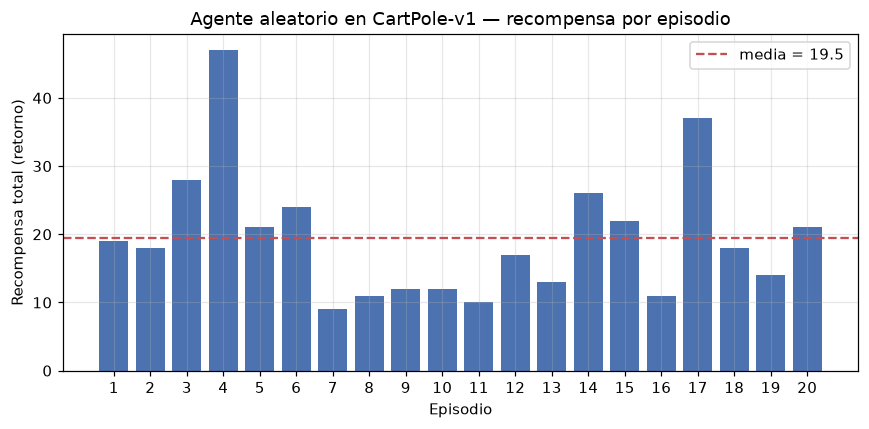

In [7]:
# Gráfica: recompensa total por episodio (agente aleatorio en CartPole)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cartpole_random["episodio"], cartpole_random["retorno"], color="#4C72B0")
media = cartpole_random["retorno"].mean()
ax.axhline(media, color="#C44E52", ls="--", label=f"media = {media:.1f}")
ax.set_xlabel("Episodio")
ax.set_ylabel("Recompensa total (retorno)")
ax.set_title("Agente aleatorio en CartPole-v1 — recompensa por episodio")
ax.set_xticks(cartpole_random["episodio"])
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "cartpole_random_rewards.png", bbox_inches="tight")
plt.show()

### 3.2 FrozenLake-v1: agente aleatorio en un segundo entorno discreto

Como segundo entorno se elige **FrozenLake-v1** (familia *Toy Text*), que
contrasta fuertemente con CartPole. Aquí **tanto la observación como la acción son
discretas**: la observación es `Discrete(16)` (el índice de la casilla en una
rejilla $4\times4$) y la acción es `Discrete(4)` (izquierda, abajo, derecha,
arriba). El agente parte de la esquina superior izquierda y debe llegar a la meta
sin caer en los agujeros; la recompensa es **dispersa**: vale `1` solo si alcanza
la meta y `0` en cualquier otro caso. Por defecto el lago es *resbaladizo*
(`is_slippery=True`), así que la acción elegida a veces desvía al agente hacia otra
dirección.

In [8]:
env = gym.make("FrozenLake-v1")
print("FrozenLake-v1 (is_slippery=True por defecto)")
print("  observation_space:", env.observation_space, "-> Discrete(16): casilla 0..15")
print("  action_space     :", env.action_space, "-> Discrete(4): 0=izq, 1=abajo, 2=der, 3=arriba")
print("  recompensa: 1 si llega a la meta, 0 en caso contrario (dispersa)")
env.close()

FrozenLake-v1 (is_slippery=True por defecto)
  observation_space: Discrete(16) -> Discrete(16): casilla 0..15
  action_space     : Discrete(4) -> Discrete(4): 0=izq, 1=abajo, 2=der, 3=arriba
  recompensa: 1 si llega a la meta, 0 en caso contrario (dispersa)


In [9]:
# Agente aleatorio durante N_EP episodios completos
frozen_random = run_agent("FrozenLake-v1", random_action, n_episodes=N_EP)
print(frozen_random.to_string(index=False))
exitos = int(frozen_random["retorno"].sum())
print(f"\nÉxitos (llegó a la meta): {exitos}/{N_EP} episodios")

# Tasa de éxito sobre muchos más episodios, para cuantificar el comportamiento
tasa = run_agent("FrozenLake-v1", random_action, n_episodes=500, base_seed=500)
print(f"Tasa de éxito en 500 episodios: {100 * tasa['retorno'].mean():.1f}%  "
      f"(pasos medios por episodio: {tasa['pasos'].mean():.1f})")

 episodio  pasos  retorno
        1     12      0.0
        2      5      0.0
        3      7      0.0
        4      6      0.0
        5     13      0.0
        6      3      0.0
        7     11      1.0
        8      2      0.0
        9      3      0.0
       10      8      0.0
       11      8      0.0
       12     11      0.0
       13      7      0.0
       14      2      0.0
       15     10      0.0
       16     11      0.0
       17      5      0.0
       18      2      0.0
       19     40      0.0
       20      6      0.0

Éxitos (llegó a la meta): 1/20 episodios


Tasa de éxito en 500 episodios: 2.4%  (pasos medios por episodio: 7.8)


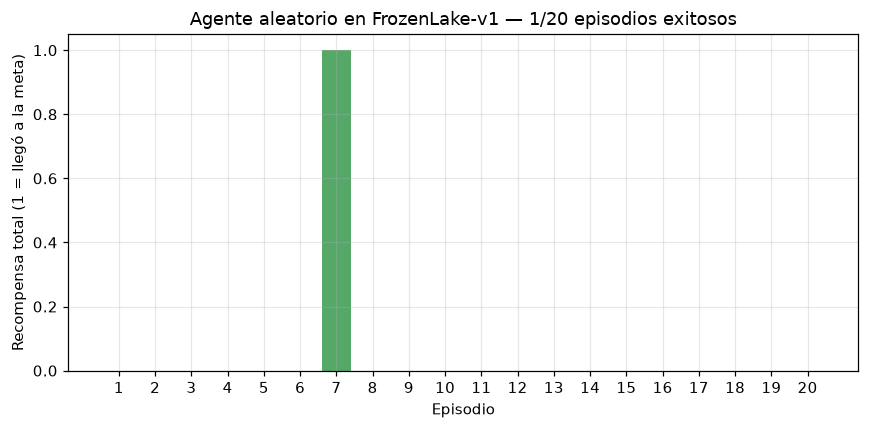

In [10]:
# Gráfica: recompensa por episodio (agente aleatorio en FrozenLake)
fig, ax = plt.subplots(figsize=(8, 4))
colores = ["#55A868" if r > 0 else "#BBBBBB" for r in frozen_random["retorno"]]
ax.bar(frozen_random["episodio"], frozen_random["retorno"], color=colores)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Episodio")
ax.set_ylabel("Recompensa total (1 = llegó a la meta)")
ax.set_title(f"Agente aleatorio en FrozenLake-v1 — {exitos}/{N_EP} episodios exitosos")
ax.set_xticks(frozen_random["episodio"])
fig.tight_layout()
fig.savefig(FIG_DIR / "frozenlake_random_rewards.png", bbox_inches="tight")
plt.show()

Con recompensa dispersa, superficie resbaladiza y una única secuencia de acciones
que conduce a la meta, el agente aleatorio prácticamente **no resuelve** el
entorno: la mayoría de episodios terminan en un agujero con retorno `0`. Esto
contrasta con CartPole, donde cualquier secuencia de acciones acumula recompensa
mientras el poste no caiga.